## SNR plots
Correct version 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import nest
import os
import sys
Path = os.getcwd()
from matplotlib.ticker import FormatStrFormatter
sys.path.append(Path)
from utilities1 import *
from build_simulation import *
from build_network  import *


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:22

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
def SNR(sim_times, a=0, sd=250, second_sine=False, f=10, psd_segments=16,
             bin_size=0.25, log=False, beat=20, save_fig=False, seed=42, N=1, return_SNR=False):
    """Computes SNR as a function of simulation time"""

    plt.rcParams["font.family"] = "DejaVu Serif"
    colors = ["#006D5B", "#89CFF0", "#FF6347", "#FFD700", "#4682B4", "#2E8B57", "#D2691E", "#8B008B", "#708090"]
    colors = ["#006D5B", "#B22222", "steelblue", "#FFD700", "#4682B4", "#2E8B57", "#D2691E", "#8B008B", "#708090"]
    
    SNR_max = []
    
    # Histogram
    for k in range(N):
       
        seed = np.random.randint(0,1e6)
        
    
        results = build_simulation(sim_time=np.max(sim_times), noisy=True, second_sine=second_sine, f1=f, a=a, SD=sd, seed=seed, resolution=0.25)
                
        spike_times = results["spike_times"]
     
        SNR_list = []
        sim_times_valid = []
        SNR_lists = []
        

        
        noise_window = 5

        for i,t in enumerate(sim_times):
            
            #finding PSD and averaging over noise [f-5Hz,f+5Hz]
            freqs, psd_values = psd_welch(spike_times[spike_times <= t], t, bin_size=bin_size, segments=psd_segments, 
                                          f=f)
        
            psd_index = np.argmin(np.abs(freqs-beat)) # index closest to beat frequency  
            noise_mask = (freqs >= (freqs[psd_index]  - noise_window)) & (freqs <= (freqs[psd_index] + noise_window)) & (freqs != freqs[psd_index])
            local_noise = psd_values[noise_mask]
            noise_avg = np.mean(local_noise)
            
            
            # Calculating SNR
            if noise_avg > 0:
                SNR = ((psd_values[psd_index]) / noise_avg)
                SNR_list.append(SNR)
                sim_times_valid.append(t)
                print(SNR)
            else:
                SNR = np.nan
                print (SNR)
           
            
        SNR_lists.append(SNR_list)
            # Plotting last list of SNR only 
        if k % N == 0:
                
           
            plt.plot(np.array(sim_times_valid)/1000, SNR_list, label=f"$\Delta f$ = {beat}Hz)", color=colors[0], alpha=0.6)
            plt.title(rf"SNR vs. simulation time ($I_{{\mathrm{{I}}}}$ = {a} pA, f1={f}Hz, f2={f+beat}Hz)", fontsize=16, color="#006D5B")
            plt.xlabel("Time [s]", fontsize=16)
            plt.ylabel("SNR", fontsize=16)
            plt.xlim(0,np.max(sim_times))
            ax = plt.gca()
            if log:
                ax.set_xscale("log")
                ax.set_yscale("log")
            print(f"a={a}pA, f={f}Hz, SNR={SNR:.2f}")
            plot_layout(ax)
    
        SNR_max.append(SNR)
    
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_beat{file_index}.png")):
            file_index += 1
            
        save_path = os.path.join(save_dir, f"SNR_beat{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.xlim(0,np.max(sim_times))
    plt.tight_layout()
    plt.show()
    
    if N >= 10:
        plt.figure()
        plt.hist(SNR_max, bins=10, density=True, color="teal", alpha=0.6, edgecolor='black')
        
        ax = plt.gca()
        plot_layout(ax)
        plt.tight_layout()
        save_figure(plt.gcf(), "hist-beat")
        plt.show()
        
  
    if return_SNR:
        return SNR_max
    

<>:57: SyntaxWarning:invalid escape sequence '\D'
<>:57: SyntaxWarning:invalid escape sequence '\D'
/tmp/ipykernel_280017/60898776.py:57: SyntaxWarning:invalid escape sequence '\D'



Apr 15 21:28:17 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 15 21:28:17 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
a=0pA, f=1000Hz, SNR=0.87


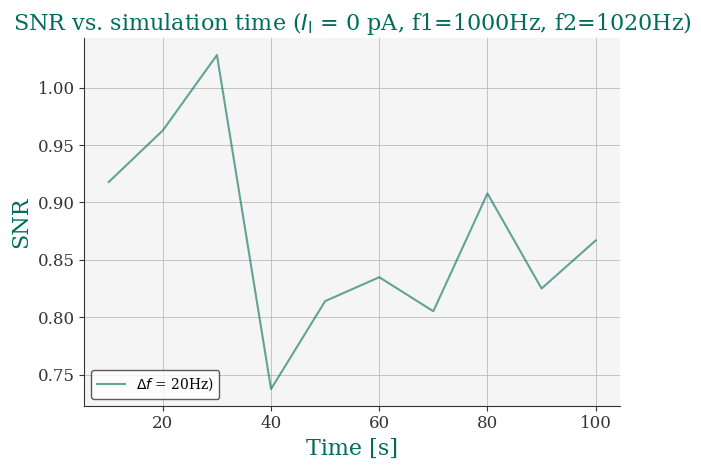

In [5]:
snr = SNR(a=0,sim_times=np.linspace(10e3,100e3,10), beat=20, f=1000, save_fig=True, N=1, return_SNR=True)

In [ ]:
snr = SNR(a=1000,second_sine=True,sim_times=np.linspace(10e3,100e3,100), beat=20, f=1000, save_fig=True, N=50, return_SNR=True)

1.1181534275157157
1.309406083505863
1.4265632000355228
1.4179109129820024
1.4025550846774013
1.5811841620099545
1.4817836252298038
1.3820859303166748
1.5038702519067975
1.5347427505564373
1.7295341614318414
1.7652800360405907
1.736325795757101
1.6987129894548332
1.51306845195854
1.538991610124289
1.6296383634300522
1.7317504224471416
1.6418390077838156
1.6365360524769847
1.6620118965480533
1.4819719658544448
1.3540464866628943
1.66315871040263
1.6746925594073785
1.8394693882285007
1.7327751636915725
1.7776207709563396
1.6851652969581026
1.4582952868397872
1.8210126819745915
1.7246136121445752
1.9124490312193094
1.95321330951075
1.8856844384868765
1.7216242334533893
1.647360636281504
1.6905020102429813
1.907900116770584
1.9334409557207155
1.9980976855399022
1.9772396633490783
1.7892148975758497
1.810054909091388
1.3892219991461505
1.960039039187788
1.925279366232979
2.1710676515834906
2.0679796089517577
2.0627367202071416
1.9675791411673755
1.869607091841026
1.9813006225118353
2.056907

a=1000pA, f=1000Hz, SNR=0.82


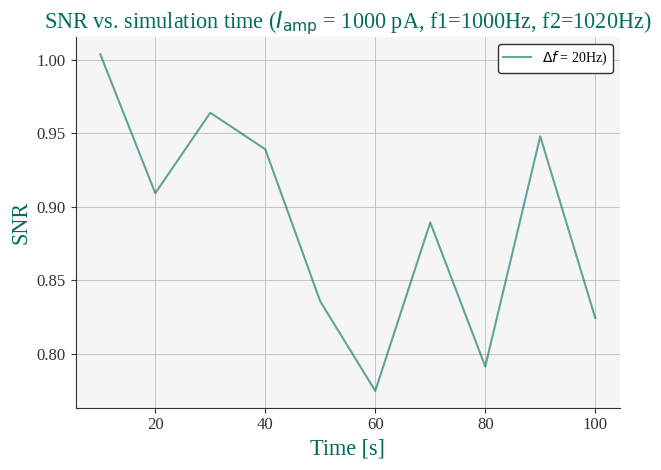

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/repo/results/hist-beat.png


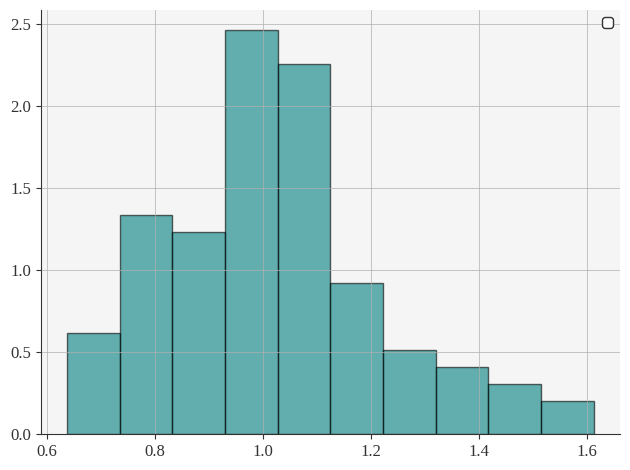

In [7]:
"""f = beat = 20 Hz"""

snr = SNR(a=1000,sim_times=np.linspace(10e3,100e3,10), beat=20, f=1000, save_fig=False, N=100, return_SNR=True)

In [25]:
print(f"mean:{np.nanmean(snr)}")
print(f"std:{np.std(snr)}")

mean:1.034138876594288
std:0.16986816325461343


In [ ]:
def SNR_amp(sim_time, a_values, sd=250, noise_window=5, second_sine=False, f_values=[10,100,1000], bin_size=0.25, resolution=0.25):
    
    colors = ["seagreen", "mediumaquamarine", "cornflowerblue","gold", "magenta" ]
    for i, f in enumerate(f_values):
        SNR_list = []
        for j, a in enumerate(a_values): 
            
            results = build_simulation(sim_time=sim_time, noisy=True, second_sine=second_sine, resolution=0.25,
                                        f1=f, a=a, SD=sd, seed=42)
                    
            spike_times = results["spike_times"]
            
            results_noise = build_simulation(sim_time=sim_time, noisy=True, resolution=resolution,
                                    f1=f, a=0, SD=sd, second_sine=False, seed=42)
            
    
            #spike_times_noise = results_noise["spike_times"]
            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)
          #  psd_index = np.argmin(np.abs(freqs-f)) #finner indeksen nærmest f
                
           # freqs_noise, psd_values_noise = psd(spike_times_noise, sim_time, bin_size=bin_size)
           # noise_mask = (freqs_noise >= (freqs_noise[psd_index] - noise_window)) & (freqs_noise <= (freqs_noise[psd_index] + noise_window))
           # local_noise = psd_values_noise[noise_mask]
           # noise_avg = np.mean(np.abs(local_noise))
            
            SNR = compute_SNR(freqs, psd_values,  f)
            SNR_list.append(SNR)
            
        plt.plot(a_values, SNR_list, label=f"f={f}Hz", color=colors[i])
        plt.title(f"B. SNR vs Current Amplitude", 
                  fontsize=20, fontweight='bold', color="#006D5B")
        plt.xlabel(r"$I_{\mathrm{I}}$ [pA]", fontsize=16)
        plt.ylabel("SNR", fontsize=16)
        plt.legend()
        
        ax = plt.gca()
        plot_layout(ax)
        plt.tight_layout()
        ax.set_xscale("log")
        ax.set_yscale("log")
    
        
    save_figure("SNR_vs_Iamp")       
    plt.tight_layout()
    plt.show()
    

Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/repo/results/SNR_vs_Iamp.png


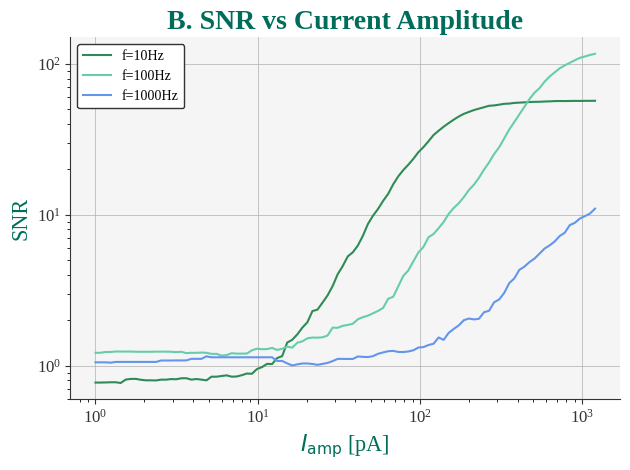

In [12]:
SNR_amp(sim_time=100e3, a_values=np.logspace(np.log10(1), np.log10(1200), 100), sd=250, second_sine=False, f_values=[10,100,1000], bin_size=0.25, resolution=0.25)

## SNR vs. frequency
Updated version - more accurate estimate of SNR \
Shows the same trend 

In [ ]:
def SNR_f(sim_time, a_values, sd=250, noise_window=5, second_sine=False, f_values=[10,20], bin_size=0.25, beat=20, save_fig=False):

    colors = ["#009879", "teal", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B"]
    for i, a in enumerate(a_values):
        SNR_list = []
       
        for j, f in enumerate(f_values): 
            
            results =  build_simulation(sim_time=sim_time, noisy=True, resolution=0.25,
                                        f1=f, a=a, SD=sd, seed=42, second_sine=second_sine, beat=beat)
            spike_times = results["spike_times"]
            
            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)
            
            SNR = compute_SNR(freqs, psd_values, f)
            
            SNR_list.append(SNR)
            
        all_SNR_values = dict(zip(f_values, SNR_list))
        all_SNR_10Hz = SNR_list[np.argmin(np.abs(np.array(f_values) - 10))]
        arg_close_to_10Hz = np.argmin(np.abs(np.array(f_values) - 10))                                      
        
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        plt.plot(f_values, SNR_list, color=colors[i], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
        plt.title(rf"A. SNR vs frequency", fontweight='bold', color="#006D5B", fontsize=20)
        plt.xlabel("Frequency [Hz]", fontsize=16)
        plt.ylabel("SNR", fontsize=16)
        plt.legend()
        ax = plt.gca() 
        plot_layout(ax)
        ax.set_yscale("log")
        ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_f_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_f_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return SNR_list
    

Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/repo/results/SNR_f_11.png


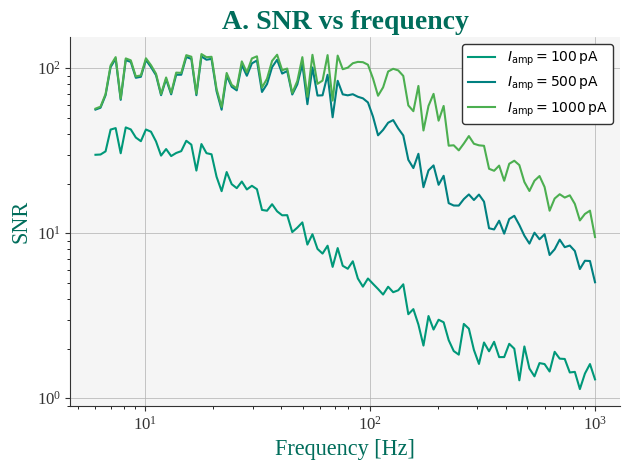

In [10]:
snr = SNR_f(sim_time=100e3, a_values=[100, 500, 1000], sd=250, second_sine=False, f_values=np.logspace(np.log10(6), np.log10(1000), 100), bin_size=0.25, save_fig=True)

In [7]:
from build_network import *


In [ ]:


def SNR_N(sim_time, NA_values, sd=250, a=1000, noise_window=5, second_sine=False, f=1000, bin_size=0.25, beat=20, save_fig=False):

    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    a_values = [1000,1500]
    for j, a in enumerate(a_values):
        SNR_list = []
        for i, N in enumerate(NA_values):
        
            results =  build_network(sim_time=sim_time, noisy=True, resolution=0.25, num_A=N,
                                        f1=f, a=a, SD=sd, seed=42, second_sine=second_sine, beat=beat)
            spike_times = results["spike_times"]

            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)

            if second_sine:
                SNR = compute_SNR(freqs, psd_values, beat)
            else:
                SNR = compute_SNR(freqs, psd_values, f)

            SNR_list.append(SNR)
            
                                            
        
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        plt.plot(NA_values, SNR_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
    plt.title(rf"A. SNR vs $N_A$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.xlabel(r"$N_A$", fontsize=16)
    plt.ylabel("SNR", fontsize=16)
    plt.legend()
    plt.xlim(0,np.max(NA_values))
    ax = plt.gca() 
    plot_layout(ax)
    #ax.set_yscale("log")
    #ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_NA_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_NA_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return SNR_list
    

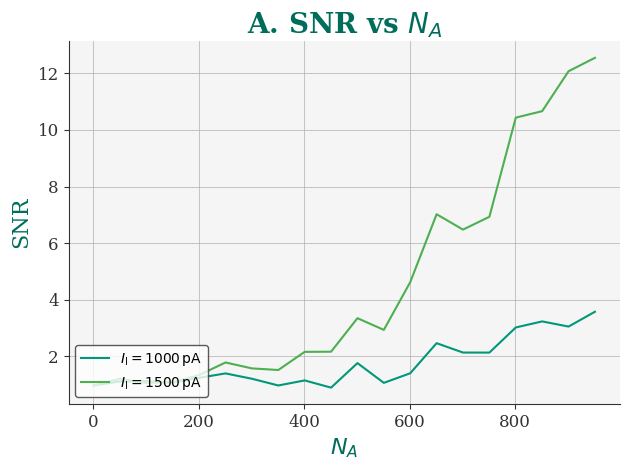

[np.float64(0.9631178823909528),
 np.float64(1.200486364389606),
 np.float64(1.0501106257226636),
 np.float64(1.0746381842049282),
 np.float64(1.330055525253255),
 np.float64(1.775274932132352),
 np.float64(1.5660152640264624),
 np.float64(1.509103222188894),
 np.float64(2.150977895844491),
 np.float64(2.1564766219287748),
 np.float64(3.341894385739603),
 np.float64(2.928214508456674),
 np.float64(4.616354381763537),
 np.float64(7.0187347157103),
 np.float64(6.476023993735196),
 np.float64(6.928892180316778),
 np.float64(10.436447517731178),
 np.float64(10.665270905368205),
 np.float64(12.078033566300423),
 np.float64(12.552177167075579)]

In [22]:
SNR_N(sim_time=100e3, NA_values=list(range(1, 1000, 50)), sd=250, a=1000, noise_window=5, second_sine=True, f=1000, bin_size=0.25, beat=20, save_fig=False)

In [5]:

def SNR_N(sim_time, NA_values, sd=250, a=1000, noise_window=5, second_sine=False, f=1000, bin_size=0.25, beat=20, save_fig=False):

    fig, ax = plt.subplots(2,1)
    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    a_values = [1000,1500]
    for j, a in enumerate(a_values):
        SNR_list = []
        fr_list = []
        for i, N in enumerate(NA_values):
        
            results =  build_network(sim_time=sim_time, noisy=True, resolution=0.25, num_A=N,
                                        f1=f, a=a, SD=sd, seed=42, second_sine=second_sine, beat=beat)
            spike_times = results["spike_times"]

            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)

            if second_sine:
                SNR = compute_SNR(freqs, psd_values, beat)
            else:
                SNR = compute_SNR(freqs, psd_values, f)

            SNR_list.append(SNR)

            firing_rate = results["Spike_rate"]

            fr_list.append(firing_rate) 
            
                                            
        
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        ax[0].plot(NA_values, SNR_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
        ax[1].plot(NA_values, fr_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
    ax[0].set_title(rf"A. SNR vs $N_A$", fontweight='bold', color="#006D5B", fontsize=20)
    ax[0].set_title(rf"A. Firing rate vs $N_A$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.xlabel(r"$N_A$", fontsize=16)
    ax[0].set_ylabel("SNR", fontsize=16)
    ax[1].set_ylabel("spikes/sec", fontsize=16)
    plt.legend()
    plt.xlim(0,np.max(NA_values))
    ax = plt.gca() 
    plot_layout(ax)
    #ax.set_yscale("log")
    #ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_NA_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_NA_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return SNR_list
    


Apr 24 10:25:47 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 24 10:25:47 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_f: 6250
arg_

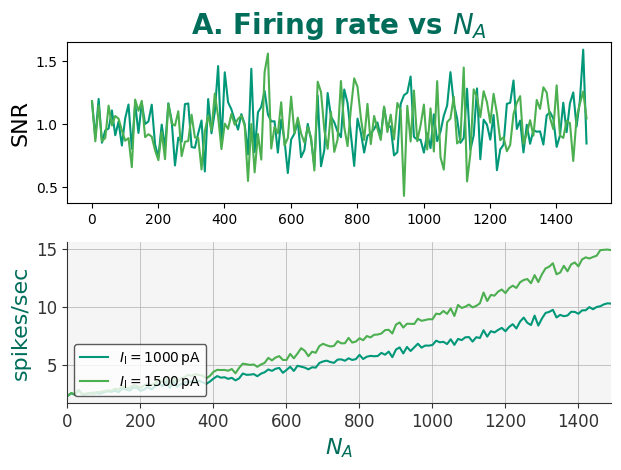

[np.float64(1.180695163219594),
 np.float64(0.8628858993754541),
 np.float64(1.1477801511454553),
 np.float64(0.8646379835702538),
 np.float64(0.890201072471254),
 np.float64(1.1464001546518767),
 np.float64(0.9895674723501816),
 np.float64(1.0646582123087136),
 np.float64(1.0432410539326369),
 np.float64(0.9509144372887353),
 np.float64(0.867707993987114),
 np.float64(0.8887346188469716),
 np.float64(0.6580183358631796),
 np.float64(1.1944312463043034),
 np.float64(1.1058249743664428),
 np.float64(1.184891652604586),
 np.float64(0.8966213102156647),
 np.float64(0.9196218436736983),
 np.float64(0.9004321928099731),
 np.float64(0.7921484436944392),
 np.float64(0.713821580157641),
 np.float64(0.9386866032271944),
 np.float64(0.7214640780979582),
 np.float64(1.1606809706303032),
 np.float64(1.004876372947284),
 np.float64(0.9880922404704523),
 np.float64(1.1019470708435501),
 np.float64(0.7457356814855773),
 np.float64(0.859508322812705),
 np.float64(0.8657174455664973),
 np.float64(1.074

In [6]:
SNR_N(sim_time=100e3, NA_values=list(range(1,1500,10)), sd=250, a=1000, noise_window=5, second_sine=False, f=1000, bin_size=0.25, beat=20, save_fig=False)

## Firing rate vs $N_A$

In [8]:
def firing_rate_NA(sim_time, NA_values, sd=250, a=1000, noise_window=5, second_sine=False, f=1000, bin_size=0.25, beat=20, save_fig=False):

    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    a_values = [1000,1500]
    for j, a in enumerate(a_values):
        fr_list = []
        for i, N in enumerate(NA_values):
        
            results =  build_network(sim_time=sim_time, noisy=True, resolution=0.25, num_A=N,
                                        f1=f, a=a, SD=sd, seed=42, second_sine=second_sine, beat=beat)
            
            firing_rate = results["Spike_rate"]

            fr_list.append(firing_rate)                            
        
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        plt.plot(NA_values, fr_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
    plt.title(rf"A. Firing rate vs $N_A$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.xlabel(r"$N_A$", fontsize=16)
    plt.ylabel("SNR", fontsize=16)
    plt.legend()
    plt.xlim(0,np.max(NA_values))
    ax = plt.gca() 
    plot_layout(ax)
    #ax.set_yscale("log")
    #ax.set_xscale("log")
    ax = plt.gca()
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_NA_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_NA_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return fr_list
    


Apr 20 14:30:31 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 20 14:30:31 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.


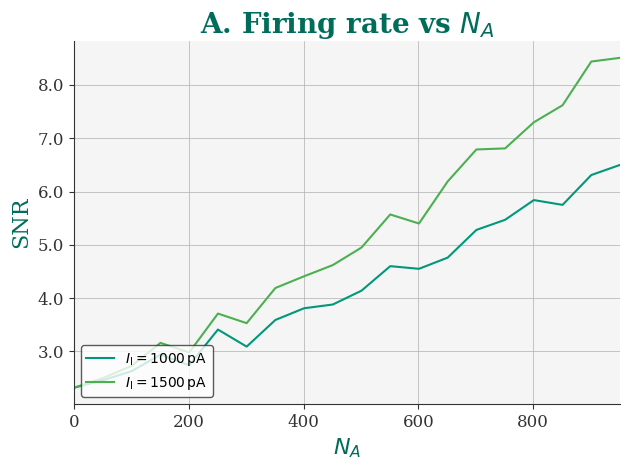

[2.32,
 2.5,
 2.73,
 3.16,
 2.98,
 3.7100000000000004,
 3.5300000000000002,
 4.19,
 4.41,
 4.62,
 4.95,
 5.57,
 5.4,
 6.19,
 6.79,
 6.8100000000000005,
 7.3,
 7.62,
 8.44,
 8.51]

In [9]:
firing_rate_NA(sim_time=100e3, NA_values=list(range(1, 1000, 50)))

## SNR as a function of Cm 

In [3]:

def SNR_C(sim_time, Cm_values, sd=250, a=1000, noise_window=5, Cm_change_domain="both",second_sine=True, f=1000, bin_size=0.25, beat=20, save_fig=False):

    plt.figure()
    #fig, ax = plt.subplots(2,1)
    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    a_values = [1000]
    for j, a in enumerate(a_values):
        SNR_list = []
        fr_list = []
        for i, C in enumerate(Cm_values):

            if Cm_change_domain == "both":
                Cm_A = C
                Cm_B = C
            elif Cm_change_domain == "A":
                Cm_A = C
                Cm_B = 100
            else:
                Cm_A = 100
                Cm_B = C
        
            results =  build_network(Cm_A=Cm_A, Cm_B=Cm_B, sim_time=sim_time, noisy=True, resolution=0.25, num_A=1000,
                                        f1=f, a=a, SD=250*C/100, seed=42, second_sine=second_sine, beat=beat)
            spike_times = results["spike_times"]

            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)

            if second_sine:
                SNR = compute_SNR(freqs, psd_values, beat)
            else:
                SNR = compute_SNR(freqs, psd_values, f)

            SNR_list.append(SNR)

            firing_rate = results["Spike_rate"]
            print(firing_rate)

            fr_list.append(firing_rate) 
            
                                            
        
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        plt.plot(Cm_values, SNR_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
       # ax[1].plot(Cm_values, fr_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
    plt.title(rf"A. SNR vs $C_m$", fontweight='bold', color="#006D5B", fontsize=20)
    #ax[0].set_title(rf"A. Firing rate vs $C_m$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.xlabel(r"$C_m$", fontsize=16)
    plt.ylabel("SNR", fontsize=16)
    #ax[1].set_ylabel("spikes/sec", fontsize=16)
    plt.legend()
    plt.xlim(0,np.max(Cm_values)) 
    #plot_layout(ax[1])
    plot_layout(plt.gca())
    #ax.set_yscale("log")
    #ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_Cm_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_Cm_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return SNR_list 

### 1. Changing Cm in all neurons 


Aug 20 11:05:29 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Aug 20 11:05:29 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
arg_f: 125
11.07
arg_f: 125
5.41
arg_f: 125
4.13
arg_f: 125
3.64
arg_f: 125
3.48
arg_f: 125
3.32
arg_f: 125
3.17
arg_f: 125
3.1
arg_f: 125
3.0300000000000002
arg_f: 125
3.0
arg_f: 125
2.97
arg_f: 125
2.92
arg_f: 125
2.9
arg_f: 125
2.8800000000000003
arg_f: 125
2.87
arg_f: 125
2.85
arg_f: 125
2.83
arg_f: 125
2.83


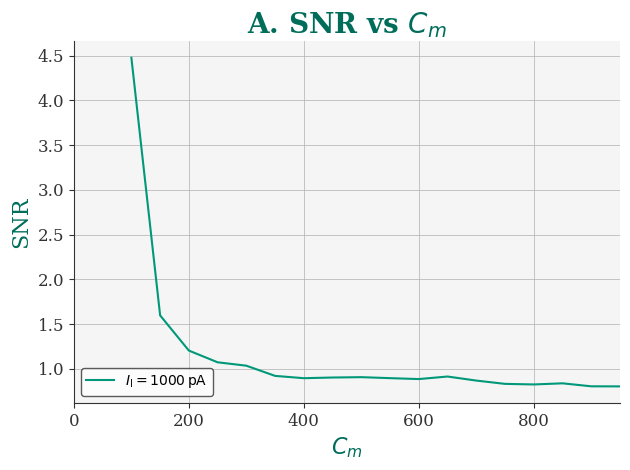

[4.477053054586883,
 1.5966778456385033,
 1.2033153323015713,
 1.07236334181549,
 1.0343938928419574,
 0.9203992886128435,
 0.8946707163705641,
 0.9022360996901871,
 0.9061112625915817,
 0.8951966586024186,
 0.8849180356960771,
 0.913253292468722,
 0.8679485345593173,
 0.8311402654548391,
 0.8246372475305727,
 0.8372700958685794,
 0.8039015558380459,
 0.8029942577639076]

In [ ]:
SNR_C(sim_time=100e3, Cm_values=list(range(100,1001,50)))

### 2. Changing Cm in presynaptic population


Sep 02 19:21:26 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Sep 02 19:21:26 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
arg_f: 125
11.05
arg_f: 125
20.19
arg_f: 125
30.09
arg_f: 125
39.910000000000004
arg_f: 125
48.69
arg_f: 125
56.86
arg_f: 125
63.96
arg_f: 125
70.71
arg_f: 125
77.17999999999999
arg_f: 125
82.62
arg_f: 125
88.27
arg_f: 125
92.86
arg_f: 125
97.17
arg_f: 125
100.91
arg_f: 125
105.30000000000001
arg_f: 125
108.72999999999999
arg_f: 125
111.5
arg_f: 125
115.21000000000001
arg_f: 125
118.42999999999999
Saved plot as: /home/tonje/master/TIS/results/SNR_Cm_2.png


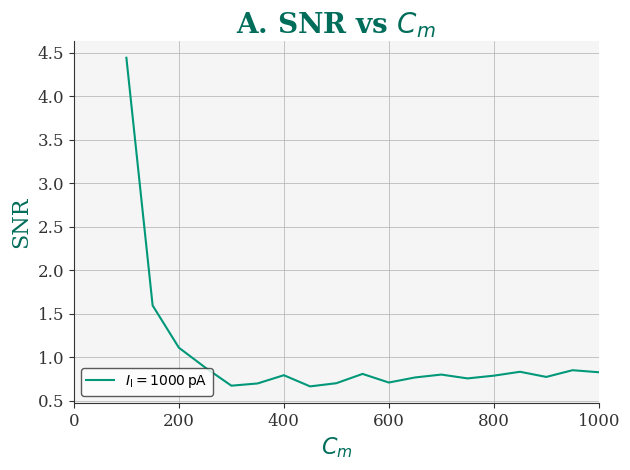

[4.444769380362544,
 1.5943334907950748,
 1.1084124468476462,
 0.8810084094075709,
 0.6711556200881008,
 0.696922690049946,
 0.7916386499079376,
 0.6630637432708888,
 0.699631463140565,
 0.8066527069934651,
 0.7075455619922443,
 0.7658478687964844,
 0.7990275173441791,
 0.7549296759400774,
 0.7863192610674372,
 0.8312537931547662,
 0.7719841834372402,
 0.8492048044024443,
 0.8259192468054501]

In [4]:
SNR_C(sim_time=100e3, Cm_values=list(range(100,1001,50)), Cm_change_domain="A", save_fig=True)

### 3. Changing Cm in postsynaptic neuron

arg_f: 125
11.04
arg_f: 125
24.59
arg_f: 125
31.89
arg_f: 125
35.53
arg_f: 125
36.92
arg_f: 125
37.26
arg_f: 125
36.91
arg_f: 125
36.24
arg_f: 125
35.45
arg_f: 125
34.37
arg_f: 125
33.480000000000004
arg_f: 125
32.309999999999995
arg_f: 125
31.07
arg_f: 125
30.06
arg_f: 125
29.03
arg_f: 125
28.11
arg_f: 125
27.14
arg_f: 125
26.22
arg_f: 125
25.38
Saved plot as: /home/tonje/master/TIS/results/SNR_Cm_3.png


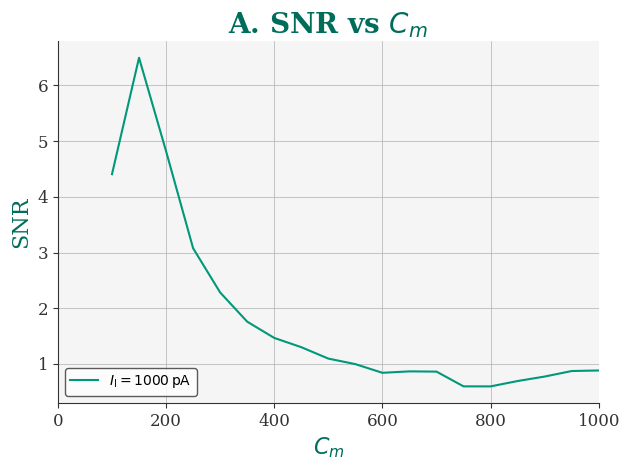

[4.405867606687651,
 6.494811858271239,
 4.817698037539802,
 3.075954408286207,
 2.2827070261621736,
 1.7587946576323195,
 1.4671211223745535,
 1.300918250550258,
 1.0961876017284375,
 0.996965931585334,
 0.841205226338598,
 0.8669203822135445,
 0.8625766671069591,
 0.5979439083564367,
 0.597395689274405,
 0.693720792254051,
 0.774133861142172,
 0.8732550116572312,
 0.8830149308214312]

In [5]:
SNR_C(sim_time=100e3, Cm_values=list(range(100,1001,50)), Cm_change_domain="B", save_fig=True)

## SNR vs R
Expecting that SNR is independent of R?

In [6]:
def SNR_R(sim_time, R_values, a_values = [1000], C=100, sd=250, a=1000, noise_window=5, second_sine=True, f=1000, bin_size=0.25, beat=20, save_fig=False): 
 
    plt.figure() 
    #fig, ax = plt.subplots(2,1) 
    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"] 
    
    for j, a in enumerate(a_values): 
        SNR_list = [] 
        fr_list = [] 
        for i, R in enumerate(R_values): 
            tau_m = C * R / 1000
         
            results =  build_network(sim_time=sim_time, noisy=True, resolution=0.25, num_A=1000, Cm=C, tau_m=tau_m, 
                                        f1=f, a=a, SD=250*C/100, seed=42, second_sine=second_sine, beat=beat) 
            spike_times = results["spike_times"] 
 
            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size) 
 
            if second_sine: 
                SNR = compute_SNR(freqs, psd_values, beat) 
            else: 
                SNR = compute_SNR(freqs, psd_values, f) 
 
            SNR_list.append(SNR) 
 
            firing_rate = results["Spike_rate"] 
 
            fr_list.append(firing_rate)  
             
                                             
         
        # Plot 
        plt.rcParams["font.family"] = "DejaVu Serif" 
        plt.plot(R_values, SNR_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$") 
        #ax[1].plot(R_values, fr_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$") 
    plt.title(rf"B. SNR vs $R$", fontweight='bold', color="#006D5B", fontsize=20) 
    #plt.title(rf"A. Firing rate vs $R$", fontweight='bold', color="#006D5B", fontsize=20) 
    plt.ylabel("SNR", fontsize=16) 
    #ax[1].set_ylabel("spikes/sec", fontsize=16) 
    plt.legend() 
    plt.xlabel(r"$R$ (M$\Omega$)", fontsize=16)
    plt.xlim(0,np.max(R_values))  
    #plot_layout(ax[1]) 
    plot_layout(plt.gca()) 
    #ax.set_yscale("log") 
    #ax.set_xscale("log") 
         
    if save_fig: 
        save_dir = os.path.join(os.getcwd(), "results") 
        os.makedirs(save_dir, exist_ok=True) 
        file_index = 1 
        while os.path.exists(os.path.join(save_dir, f"SNR_R_{file_index}.png")): 
            file_index += 1 
         
        save_path = os.path.join(save_dir, f"SNR_R_{file_index}.png") 
        plt.savefig(save_path, dpi=300, bbox_inches="tight") 
     
         
        print(f"Saved plot as: {save_path}") 
             
    plt.tight_layout() 
    plt.show() 
    return SNR_list


Aug 22 20:04:56 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Aug 22 20:04:56 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125


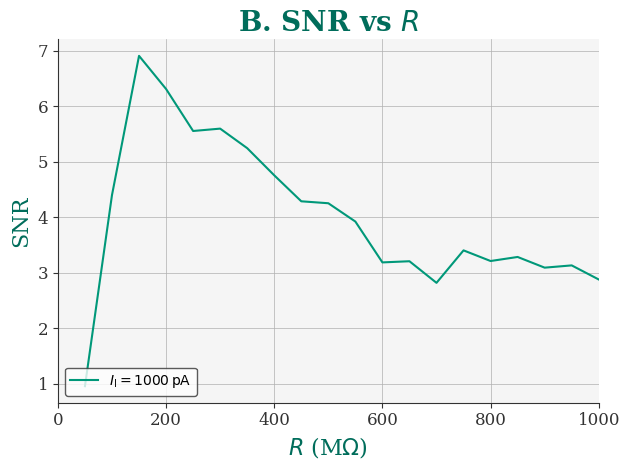

In [4]:
R_values = list(range(50, 1001, 50))
SNR_R_list = SNR_R(sim_time=100e3, R_values=R_values)


### Zooming in on the SNR vs R plot to have a closer look at the initial slope (small  values of R)

arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125


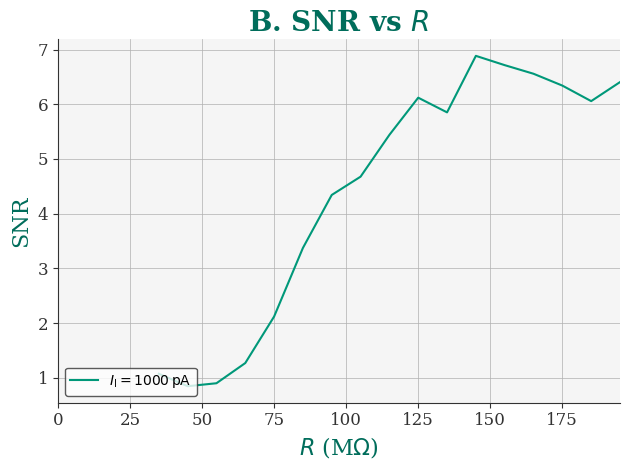

In [7]:
R_values = list(range(25, 201, 10))
SNR_R_list = SNR_R(sim_time=100e3, R_values=R_values)


### high resolution plot

arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125

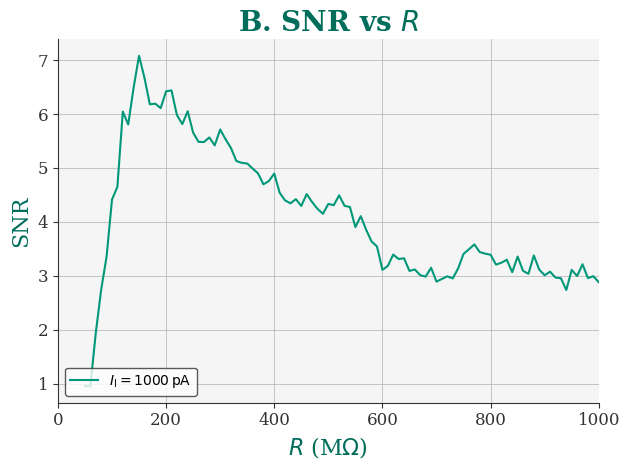

In [9]:
R_values = list(range(50, 1001, 10))
SNR_R_list = SNR_R(sim_time=100e3, R_values=R_values)

Er C mer konstant med høyere C? Se matematisk utledning i notater. Høyere Cm gir høyere tau_m og SNR er bare uavhengig av R dersom tau_m >> tau_syn_ex 

arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125
arg_f: 125


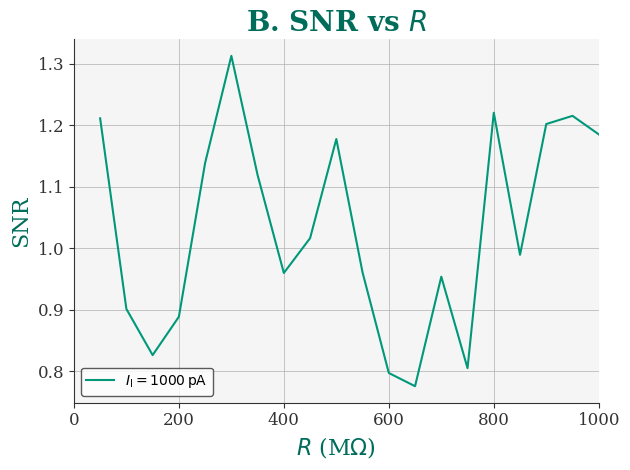

In [11]:
R_values = list(range(50, 1001, 50))
SNR_R_list = SNR_R(sim_time=100e3, C=1000, R_values=R_values, a_values=[1000])

## SNR vs w

In [6]:
def SNR_w(sim_time, w_values, C=100, sd=250, a=1000, noise_window=5, second_sine=True, f=1000, bin_size=0.25, beat=20, save_fig=False):

    plt.figure()
    #fig, ax = plt.subplots(2,1)
    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    a_values = [1000]
    for j, a in enumerate(a_values):
        SNR_list = []
        fr_list = []
        for i, w in enumerate(w_values):

            results =  build_network(sim_time=sim_time, weight=w, noisy=True, resolution=0.25, num_A=1000, Cm=C, tau_m=10,
                                        f1=f, a=a, SD=250*C/100, seed=42, second_sine=second_sine, beat=beat)
            spike_times = results["spike_times"]

            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)

            if second_sine:
                SNR = compute_SNR(freqs, psd_values, beat)
            else:
                SNR = compute_SNR(freqs, psd_values, f)

            SNR_list.append(SNR)

            firing_rate = results["Spike_rate"]
            print(firing_rate)

            fr_list.append(firing_rate) 
            
                                            
        
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        plt.plot(w_values, SNR_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
        #ax[1].plot(R_values, fr_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
    plt.title(rf"C. SNR vs $w$", fontweight='bold', color="#006D5B", fontsize=20)
    #plt.title(rf"A. Firing rate vs $R$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.ylabel("SNR", fontsize=16)
    #ax[1].set_ylabel("spikes/sec", fontsize=16)
    plt.legend()
    plt.xlim(0,np.max(w_values)) 
    #plot_layout(ax[1])
    plot_layout(plt.gca())
    #ax.set_yscale("log")
    #ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_W_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_W_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return SNR_list

In [ ]:
w_values = [0.1, 0.5, 1, 2, 5, 10, 20, 30, 40, 50]
SNR_w_list = SNR_w(sim_time=100e3, w_values=w_values)

### keeping w/C constant

In [7]:
from numpy import rint


def SNR_C_w(sim_time, Cm_values, sd=250, a=1000, noise_window=5, second_sine=True, f=1000, bin_size=0.25, beat=20, save_fig=False):

    plt.figure()
    #fig, ax = plt.subplots(2,1)
    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    a_values = [1000]
    for j, a in enumerate(a_values):
        SNR_list = []
        fr_list = []
        for i, C in enumerate(Cm_values):

            weight = C / 100 # w0 * C / C_old


        
            results =  build_network(sim_time=sim_time, noisy=True, resolution=0.25, num_A=1000, Cm=C, weight=weight, tau_m=10,
                                        f1=f, a=a, SD=250, seed=42, second_sine=second_sine, beat=beat)
            spike_times = results["spike_times"]

            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size)

            if second_sine:
                SNR = compute_SNR(freqs, psd_values, beat)
            else:
                SNR = compute_SNR(freqs, psd_values, f)

            SNR_list.append(SNR)

            firing_rate = results["Spike_rate"]
            print(f"C: {C}, Firing Rate: {firing_rate}")

            fr_list.append(firing_rate) 
            
                                            
        # Plot
        plt.rcParams["font.family"] = "DejaVu Serif"
        plt.plot(Cm_values, SNR_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
       # ax[1].plot(Cm_values, fr_list, color=colors[j], label=rf"$I_\mathrm{{I}} = {a}\,\mathrm{{pA}}$")
    plt.title(rf"D. SNR vs $C_m$ keeping w/C constant", fontweight='bold', color="#006D5B", fontsize=20)
    #ax[0].set_title(rf"A. Firing rate vs $C_m$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.xlabel(r"$C_m$ (pF)", fontsize=16)
    plt.ylabel("SNR", fontsize=16)
    #ax[1].set_ylabel("spikes/sec", fontsize=16)
    plt.legend()
    plt.xlim(0,np.max(Cm_values)) 
    #plot_layout(ax[1])
    plot_layout(plt.gca())
    #ax.set_yscale("log")
    #ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_Cm_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_Cm_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()
    plt.show()
    return SNR_list 

arg_f: 125
C: 100, Firing Rate: 11.06
arg_f: 125
C: 150, Firing Rate: 0.1
arg_f: 125
C: 200, Firing Rate: 0.0
arg_f: 125
C: 250, Firing Rate: 0.0
arg_f: 125
C: 300, Firing Rate: 0.0
arg_f: 125
C: 350, Firing Rate: 0.0
arg_f: 125
C: 400, Firing Rate: 0.0
arg_f: 125
C: 450, Firing Rate: 0.0
arg_f: 125
C: 500, Firing Rate: 0.0
arg_f: 125
C: 550, Firing Rate: 0.0
arg_f: 125
C: 600, Firing Rate: 0.0
arg_f: 125
C: 650, Firing Rate: 0.0
arg_f: 125
C: 700, Firing Rate: 0.0
arg_f: 125
C: 750, Firing Rate: 0.0
arg_f: 125
C: 800, Firing Rate: 0.0
arg_f: 125
C: 850, Firing Rate: 0.0
arg_f: 125
C: 900, Firing Rate: 0.0
arg_f: 125
C: 950, Firing Rate: 0.0
arg_f: 125
C: 1000, Firing Rate: 0.0


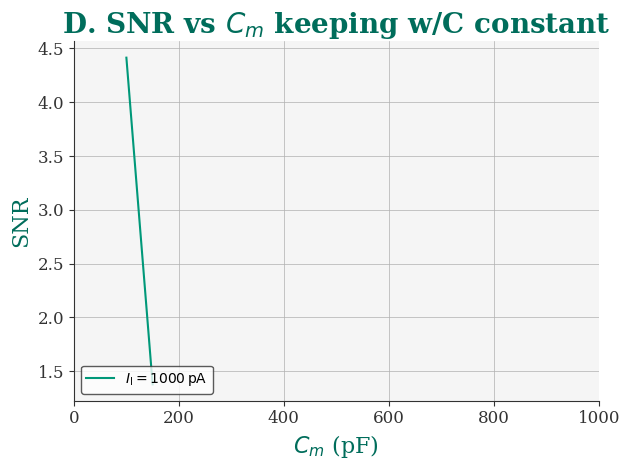

In [8]:
SNR_C_w_list = SNR_C_w(sim_time=100e3, Cm_values=list(range(100,1001,50)))

arg_f: 125
C: 10, Firing Rate: 237.88
arg_f: 125
C: 20, Firing Rate: 208.45
arg_f: 125
C: 30, Firing Rate: 173.03
arg_f: 125
C: 40, Firing Rate: 139.41
arg_f: 125
C: 50, Firing Rate: 108.8
arg_f: 125
C: 60, Firing Rate: 81.30999999999999
arg_f: 125
C: 70, Firing Rate: 57.51
arg_f: 125
C: 80, Firing Rate: 37.519999999999996
arg_f: 125
C: 90, Firing Rate: 21.930000000000003
arg_f: 125
C: 100, Firing Rate: 11.07
arg_f: 125
C: 110, Firing Rate: 4.84
arg_f: 125
C: 120, Firing Rate: 1.8
arg_f: 125
C: 130, Firing Rate: 0.64
arg_f: 125
C: 140, Firing Rate: 0.19
arg_f: 125
C: 150, Firing Rate: 0.1
arg_f: 125
C: 160, Firing Rate: 0.04
arg_f: 125
C: 170, Firing Rate: 0.01
arg_f: 125
C: 180, Firing Rate: 0.0
arg_f: 125
C: 190, Firing Rate: 0.0
arg_f: 125
C: 200, Firing Rate: 0.0


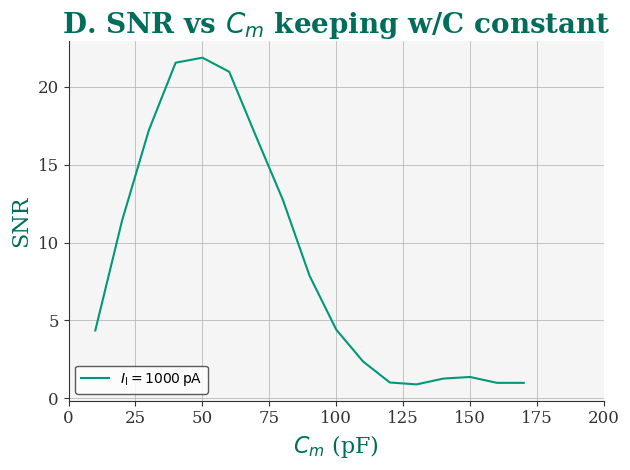

In [9]:
SNR_C_w_list = SNR_C_w(sim_time=100e3, Cm_values=list(range(10,201,10)))

### Med endret verdi av w/C